In [1]:
import os

raw_path = "../data/raw"

print("Files in raw data folder:")
for file in os.listdir(raw_path):
    print(file)

Files in raw data folder:
LD2011_2014.txt
__MACOSX


In [2]:
import os

for root, dirs, files in os.walk("../data/raw"):
    for file in files:
        print(os.path.join(root, file))

../data/raw\LD2011_2014.txt
../data/raw\__MACOSX\._LD2011_2014.txt


In [4]:
import os

raw_path = "../data/raw"

print("Files found:")
for root, dirs, files in os.walk(raw_path):
    for file in files:
        full_path = os.path.join(root, file)
        size_mb = os.path.getsize(full_path) / (1024 * 1024)
        print(f"{full_path}  |  {size_mb:.2f} MB")

Files found:
../data/raw\._LD2011_2014.txt  |  0.00 MB
../data/raw\LD2011_2014.txt  |  678.06 MB


In [7]:
import pandas as pd

file_path = "../data/raw/LD2011_2014.txt"

df = pd.read_csv(
    file_path,
    sep=";",
    decimal=","
)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Shape: (140256, 371)

First 5 rows:


,Unnamed: 0,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
0,2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df.rename(columns={df.columns[0]: "timestamp"}, inplace=True)

df["timestamp"] = pd.to_datetime(df["timestamp"])

print(df.head())
print("\nTimestamp type:")
print(df["timestamp"].dtype)

            timestamp  MT_001  MT_002  MT_003  MT_004  MT_005  MT_006  MT_007  \
0 2011-01-01 00:15:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
1 2011-01-01 00:30:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2 2011-01-01 00:45:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3 2011-01-01 01:00:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4 2011-01-01 01:15:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

   MT_008  MT_009  ...  MT_361  MT_362  MT_363  MT_364  MT_365  MT_366  \
0     0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0     0.0   
1     0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0     0.0   
2     0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0     0.0   
3     0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0     0.0   
4     0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0     0.0   

   MT_367  MT_368  MT_369  MT_370  
0     0.0     0.0     0.0     0.

In [9]:
print("Total demand minimum:", df_demand["demand"].min())
print("Total demand maximum:", df_demand["demand"].max())
print("Total demand mean:", df_demand["demand"].mean())

print("\nFirst non-zero records:")
display(
    df_demand[df_demand["demand"] > 0].head(10)
)

NameError: name 'df_demand' is not defined

In [10]:
# ============================================
# CREATE TOTAL ELECTRICITY DEMAND
# ============================================

# Make a copy of the original dataframe
df_demand = df.copy()

# Find all electricity meter columns
meter_columns = [
    col for col in df_demand.columns
    if col.startswith("MT_")
]

print("Number of meters:", len(meter_columns))

# Calculate total electricity demand
df_demand["demand"] = df_demand[meter_columns].sum(axis=1)

# Keep only timestamp and total demand
df_demand = df_demand[["timestamp", "demand"]]

print("\nDataset shape:")
print(df_demand.shape)

print("\nFirst 10 rows:")
display(df_demand.head(10))

Number of meters: 370

Dataset shape:
(140256, 2)

First 10 rows:


,timestamp,demand
0,2011-01-01 00:15:00,68513.115338
1,2011-01-01 00:30:00,69180.304361
2,2011-01-01 00:45:00,69364.850573
3,2011-01-01 01:00:00,68350.480660
4,2011-01-01 01:15:00,66166.874303
5,2011-01-01 01:30:00,64843.191940
6,2011-01-01 01:45:00,66017.963844
7,2011-01-01 02:00:00,65345.513794
8,2011-01-01 02:15:00,65567.578171
9,2011-01-01 02:30:00,65765.802247


In [11]:
# ============================================
# CHECK WHETHER DEMAND IS ACTUALLY ZERO
# ============================================

print("Total demand minimum:", df_demand["demand"].min())
print("Total demand maximum:", df_demand["demand"].max())
print("Total demand mean:", df_demand["demand"].mean())

print("\nFirst non-zero records:")

display(
    df_demand[df_demand["demand"] > 0].head(10)
)

Total demand minimum: 342.5955085040956
Total demand maximum: 452652.5955674096
Total demand mean: 195556.9425263531

First non-zero records:


,timestamp,demand
0,2011-01-01 00:15:00,68513.115338
1,2011-01-01 00:30:00,69180.304361
2,2011-01-01 00:45:00,69364.850573
3,2011-01-01 01:00:00,68350.480660
4,2011-01-01 01:15:00,66166.874303
5,2011-01-01 01:30:00,64843.191940
6,2011-01-01 01:45:00,66017.963844
7,2011-01-01 02:00:00,65345.513794
8,2011-01-01 02:15:00,65567.578171
9,2011-01-01 02:30:00,65765.802247


In [12]:
# ============================================
# STEP 8: CHECK TIME RANGE AND TIMESTAMPS
# ============================================

print("Starting timestamp:")
print(df_demand["timestamp"].min())

print("\nEnding timestamp:")
print(df_demand["timestamp"].max())

print("\nTotal records:")
print(len(df_demand))

# Check for missing timestamps
print("\nMissing timestamps:")
print(df_demand["timestamp"].isna().sum())

# Check duplicate timestamps
print("\nDuplicate timestamps:")
print(df_demand["timestamp"].duplicated().sum())

# Check time interval
print("\nMost common time interval:")
print(
    df_demand["timestamp"]
    .diff()
    .value_counts()
    .head(5)
)

Starting timestamp:
2011-01-01 00:15:00

Ending timestamp:
2015-01-01 00:00:00

Total records:
140256

Missing timestamps:
0

Duplicate timestamps:
0

Most common time interval:
timestamp
0 days 00:15:00    140255
Name: count, dtype: int64


In [13]:
# ============================================
# STEP 9: CHECK MISSING DEMAND VALUES
# ============================================

print("Missing demand values:")
print(df_demand["demand"].isna().sum())

print("\nInfinite demand values:")

import numpy as np

print(
    np.isinf(df_demand["demand"]).sum()
)

Missing demand values:
0

Infinite demand values:
0


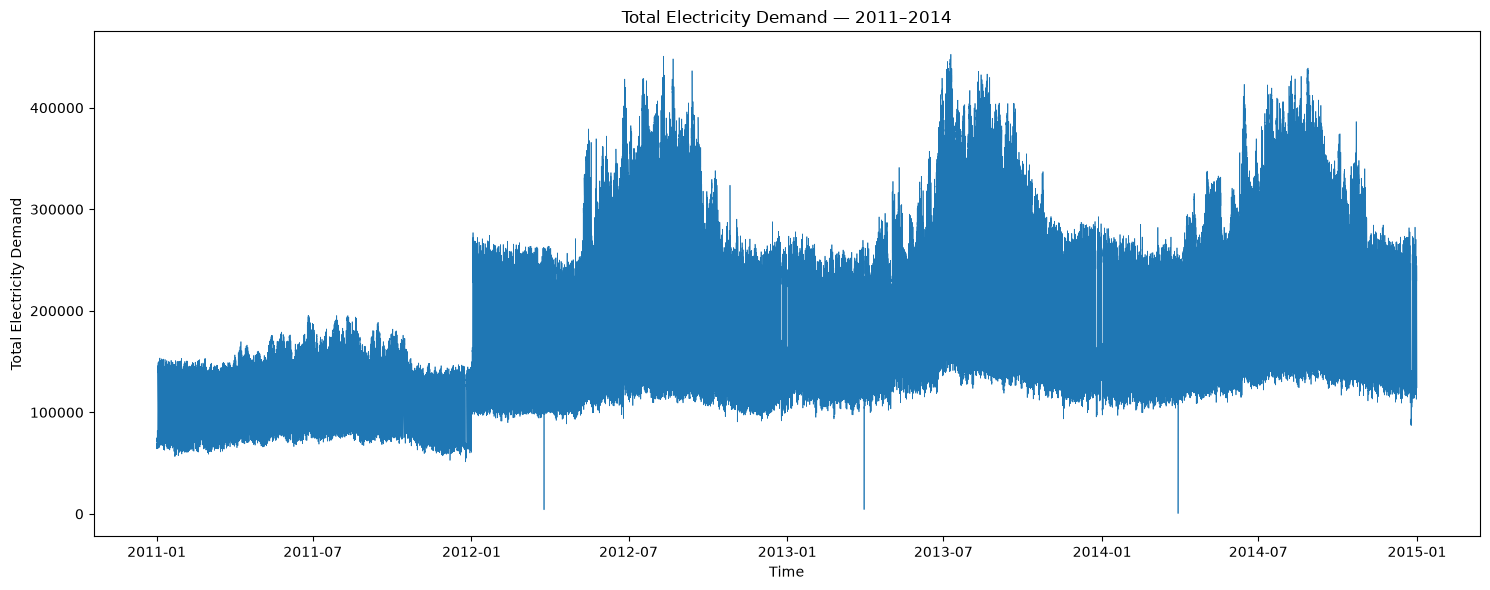

In [14]:
# ============================================
# STEP 10: PLOT ELECTRICITY DEMAND
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    df_demand["timestamp"],
    df_demand["demand"],
    linewidth=0.5
)

plt.xlabel("Time")
plt.ylabel("Total Electricity Demand")
plt.title("Total Electricity Demand — 2011–2014")

plt.tight_layout()
plt.show()

Records in selected month:
2975


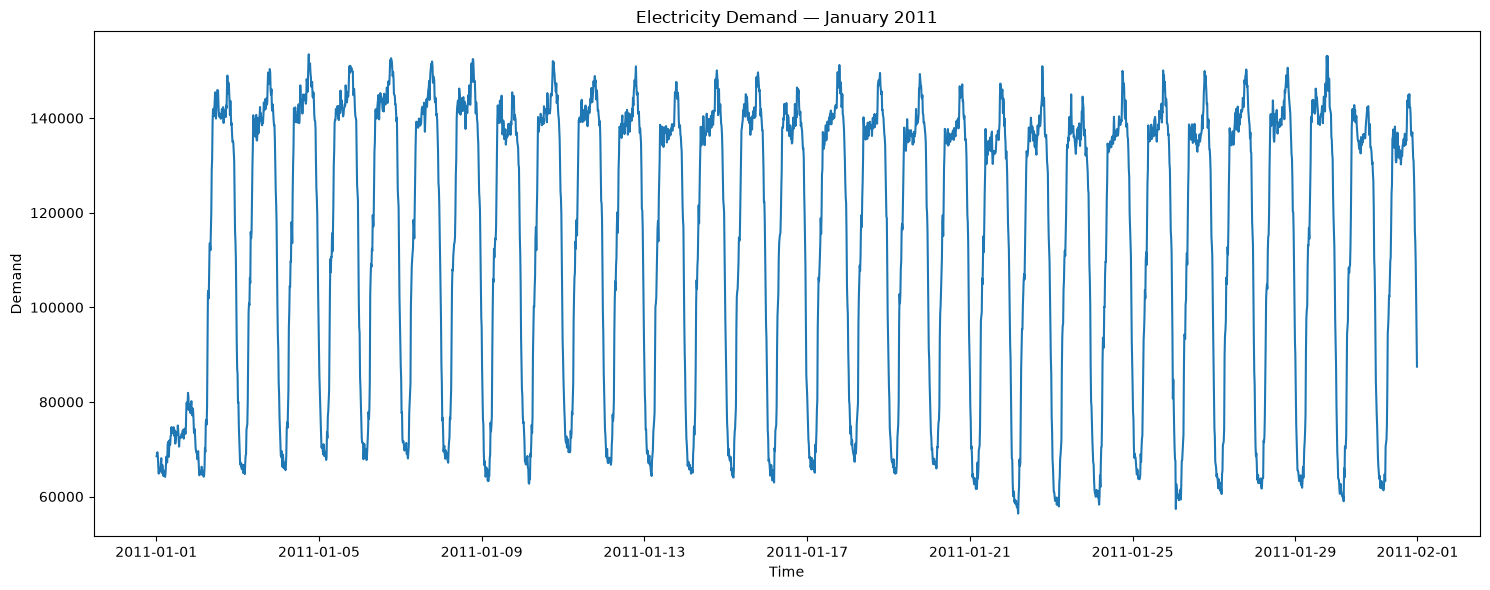

In [15]:
# ============================================
# STEP 11: ZOOM INTO ONE MONTH
# ============================================

start_date = "2011-01-01"
end_date = "2011-02-01"

df_month = df_demand[
    (df_demand["timestamp"] >= start_date) &
    (df_demand["timestamp"] < end_date)
]

print("Records in selected month:")
print(len(df_month))

plt.figure(figsize=(15, 6))

plt.plot(
    df_month["timestamp"],
    df_month["demand"]
)

plt.xlabel("Time")
plt.ylabel("Demand")
plt.title("Electricity Demand — January 2011")

plt.tight_layout()
plt.show()

In [16]:
# ============================================
# STEP 12: CLEAN DEMAND DATA
# ============================================

# Make a copy
clean_df = df_demand.copy()

# Sort by timestamp
clean_df = clean_df.sort_values("timestamp")

# Remove duplicate timestamps
clean_df = clean_df.drop_duplicates(
    subset="timestamp",
    keep="first"
)

# Remove missing timestamp rows
clean_df = clean_df.dropna(
    subset=["timestamp"]
)

# Remove missing demand rows
clean_df = clean_df.dropna(
    subset=["demand"]
)

# Remove infinite values
clean_df = clean_df[
    np.isfinite(clean_df["demand"])
]

# Reset index
clean_df = clean_df.reset_index(drop=True)

print("Cleaned dataset shape:")
print(clean_df.shape)

print("\nFirst 5 rows:")
display(clean_df.head())

print("\nLast 5 rows:")
display(clean_df.tail())

Cleaned dataset shape:
(140256, 2)

First 5 rows:


,timestamp,demand
0,2011-01-01 00:15:00,68513.115338
1,2011-01-01 00:30:00,69180.304361
2,2011-01-01 00:45:00,69364.850573
3,2011-01-01 01:00:00,68350.480660
4,2011-01-01 01:15:00,66166.874303



Last 5 rows:


,timestamp,demand
140251,2014-12-31 23:00:00,132288.754939
140252,2014-12-31 23:15:00,128543.516567
140253,2014-12-31 23:30:00,127478.208411
140254,2014-12-31 23:45:00,125641.710272
140255,2015-01-01 00:00:00,124214.199215


In [17]:
# ============================================
# STEP 13: VERIFY CLEAN DATA
# ============================================

print("Missing timestamps:",
      clean_df["timestamp"].isna().sum())

print("Missing demand:",
      clean_df["demand"].isna().sum())

print("Duplicate timestamps:",
      clean_df["timestamp"].duplicated().sum())

print("Negative demand:",
      (clean_df["demand"] < 0).sum())

print("Infinite demand:",
      np.isinf(clean_df["demand"]).sum())

Missing timestamps: 0
Missing demand: 0
Duplicate timestamps: 0
Negative demand: 0
Infinite demand: 0


In [18]:
# ============================================
# STEP 14: CHECK TIME GAPS
# ============================================

time_diff = clean_df["timestamp"].diff()

print("Time interval frequency:")
print(time_diff.value_counts().head(10))

# Find intervals that are NOT 15 minutes
unexpected_intervals = clean_df[
    time_diff.notna() &
    (time_diff != pd.Timedelta(minutes=15))
]

print("\nNumber of unexpected time intervals:")
print(len(unexpected_intervals))

print("\nFirst unexpected intervals:")
display(unexpected_intervals.head(10))

Time interval frequency:
timestamp
0 days 00:15:00    140255
Name: count, dtype: int64

Number of unexpected time intervals:
0

First unexpected intervals:


,timestamp,demand
